# 03 - Apriori Modeling (Association Rules Mining)

Mục tiêu:
- Khai thác luật kết hợp bằng Apriori
- Phát hiện tổ hợp đặc điểm nhân viên liên quan đến Attrition
- Lọc luật theo support / confidence / lift
- Phân tích và trực quan hóa luật
- Lưu luật đã lọc để sử dụng cho các bước tiếp theo

In [6]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Thiết lập project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.mining.association import (
    discretize_features,
    build_transactions,
    mine_association_rules,
    split_rules_by_attrition
)

In [7]:
df = pd.read_csv("../data/processed/hr_processed.csv")
print(df.shape)
df.head()

(1480, 53)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,SalarySlab_15k+,SalarySlab_5k-10k,SalarySlab_Upto 5k,OverTime_Yes,Attrition
0,-2.07305,-1.417860,-0.765246,0.087146,0.252402,-0.582896,0.379185,-0.963504,0.249148,-1.082217,...,False,False,False,False,True,False,False,True,False,1
1,-2.07305,0.026342,0.095926,0.087146,1.167977,0.155242,-1.023800,-0.963504,0.249148,-1.129039,...,False,False,True,False,True,False,False,True,False,0
2,-2.07305,1.252176,-0.519197,0.087146,-0.663173,0.155242,0.379185,-0.963504,-0.656844,-0.984743,...,False,False,True,False,True,False,False,True,True,1
3,-2.07305,-1.276417,-0.519197,-0.889941,-0.663173,0.352079,0.379185,-0.963504,1.155139,-1.160750,...,True,False,False,False,True,False,False,True,False,0
4,-2.07305,-1.375675,-0.150123,-1.867028,0.252402,0.696543,0.379185,-0.963504,0.249148,-0.979210,...,False,False,False,False,True,False,False,True,False,1


# Association Rules - Apirori

In [ ]:
# Tham số Apriori
# Tham số sinh luật
MIN_SUPPORT = 0.02

# Tham số lọc luật
FILTER_MIN_SUPPORT = 0.05
FILTER_MIN_CONF = 0.6
FILTER_MIN_LIFT = 1.2
FILTER_MAX_ANTECEDENTS = 3
FILTER_MAX_CONSEQUENTS = 1

print("Apriori parameters:")
print(f"- Min support (generate): {MIN_SUPPORT}")
print(f"- Min support (filter)  : {FILTER_MIN_SUPPORT}")
print(f"- Min confidence        : {FILTER_MIN_CONF}")
print(f"- Min lift              : {FILTER_MIN_LIFT}")

Apriori parameters:
- Min support (generate): 0.02
- Min support (filter)  : 0.05
- Min confidence        : 0.6
- Min lift              : 1.2


In [9]:
df_disc = discretize_features(df)
transactions = build_transactions(df_disc)

print(f"Số transaction                 : {transactions.shape[0]:,}")
print(f"Số item trung bình / transaction: {transactions.sum(axis=1).mean():.2f}")

transactions.head()

Số transaction                 : 1,480
Số item trung bình / transaction: 7.00


,Age_bin_nan,"MonthlyIncome_bin_(0, 3000]",MonthlyIncome_bin_nan,"TotalWorkingYears_bin_(0, 5]",TotalWorkingYears_bin_nan,"YearsAtCompany_bin_(0, 2]","YearsAtCompany_bin_(2, 5]","YearsAtCompany_bin_(5, 10]",YearsAtCompany_bin_nan,OverTime_Yes_False,OverTime_Yes_True,JobLevel_-0.0586905839678013,JobLevel_-0.963503753471408,JobLevel_0.8461225855358053,JobLevel_1.7509357550394118,JobLevel_2.6557489245430186,AttritionLabel_Leave,AttritionLabel_Stay
0,True,False,True,False,True,False,False,False,True,True,False,False,True,False,False,False,True,False
1,True,False,True,False,True,False,False,False,True,True,False,False,True,False,False,False,False,True
2,True,False,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False
3,True,False,True,False,True,False,False,False,True,True,False,False,True,False,False,False,False,True
4,True,False,True,False,True,False,False,False,True,True,False,False,True,False,False,False,True,False


In [10]:
# Khai phá luật kết hợp (Apriori)
rules_ap = mine_association_rules(
    transactions,
    min_support=MIN_SUPPORT,
)

print(f"Tổng số luật sinh ra ban đầu: {rules_ap.shape[0]:,}")

rules_ap.head()

Tổng số luật sinh ra ban đầu: 21,324


c:\Users\Admin\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Age_bin_nan),"(MonthlyIncome_bin_(0, 3000])",1.000000,0.335811,0.335811,0.335811,1.0,1.0,0.0,1.0,0.0,0.335811,0.0,0.667905
1,"(MonthlyIncome_bin_(0, 3000])",(Age_bin_nan),0.335811,1.000000,0.335811,1.000000,1.0,1.0,0.0,inf,0.0,0.335811,0.0,0.667905
2,(Age_bin_nan),(MonthlyIncome_bin_nan),1.000000,0.664189,0.664189,0.664189,1.0,1.0,0.0,1.0,0.0,0.664189,0.0,0.832095
3,(MonthlyIncome_bin_nan),(Age_bin_nan),0.664189,1.000000,0.664189,1.000000,1.0,1.0,0.0,inf,0.0,0.664189,0.0,0.832095
4,(Age_bin_nan),"(TotalWorkingYears_bin_(0, 5])",1.000000,0.347973,0.347973,0.347973,1.0,1.0,0.0,1.0,0.0,0.347973,0.0,0.673986


In [11]:
# ===== LỌC, SẮP XẾP & CHỌN TOP-K LUẬT (KHÔNG ÉP CONSEQUENT) =====

n_rules_raw = rules_ap.shape[0]
print("Tổng số luật ban đầu:", n_rules_raw)

rules_filtered = rules_ap[
    (rules_ap["support"] >= FILTER_MIN_SUPPORT) &
    (rules_ap["confidence"] >= FILTER_MIN_CONF) &
    (rules_ap["lift"] >= FILTER_MIN_LIFT) &
    (rules_ap["antecedents"].apply(len) <= FILTER_MAX_ANTECEDENTS) &
    (rules_ap["consequents"].apply(len) <= FILTER_MAX_CONSEQUENTS)
].copy()

print("Sau lọc ngưỡng cơ bản:", rules_filtered.shape[0])

# ===== LOẠI LUẬT CHỨA NaN =====
def has_nan_item(items):
    return any("nan" in str(item).lower() for item in items)

rules_filtered = rules_filtered[
    ~rules_filtered["antecedents"].apply(has_nan_item) &
    ~rules_filtered["consequents"].apply(has_nan_item)
]

print("Sau loại luật chứa NaN:", rules_filtered.shape[0])

# ===== LOẠI LUẬT HIỂN NHIÊN =====
def is_trivial_rule(row):
    a = " ".join(row["antecedents"])
    c = " ".join(row["consequents"])
    return (
        ("JobLevel" in a and "MonthlyIncome" in c) or
        ("MonthlyIncome" in a and "JobLevel" in c)
    )

rules_filtered = rules_filtered[
    ~rules_filtered.apply(is_trivial_rule, axis=1)
]

print("Sau loại luật hiển nhiên:", rules_filtered.shape[0])

# ===== SORT & TOP-K =====
rules_filtered = rules_filtered.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
)

TOP_K = 100
rules_topk = rules_filtered.head(TOP_K)

print(f"Số luật cuối cùng (Top-{TOP_K}): {rules_topk.shape[0]}")

cols_preview = ["antecedents", "consequents", "support", "confidence", "lift"]
rules_topk[cols_preview].head(10)

Tổng số luật ban đầu: 21324
Sau lọc ngưỡng cơ bản: 290
Sau loại luật chứa NaN: 49
Sau loại luật hiển nhiên: 31
Số luật cuối cùng (Top-100): 31


,antecedents,consequents,support,confidence,lift
81,"(YearsAtCompany_bin_(2, 5])","(TotalWorkingYears_bin_(0, 5])",0.062838,1.000000,2.873786
1278,"(YearsAtCompany_bin_(2, 5], AttritionLabel_Stay)","(TotalWorkingYears_bin_(0, 5])",0.057432,1.000000,2.873786
720,"(MonthlyIncome_bin_(0, 3000], YearsAtCompany_b...","(TotalWorkingYears_bin_(0, 5])",0.056757,1.000000,2.873786
4433,"(MonthlyIncome_bin_(0, 3000], YearsAtCompany_b...","(TotalWorkingYears_bin_(0, 5])",0.051351,1.000000,2.873786
95,(JobLevel_1.7509357550394118),"(TotalWorkingYears_bin_(0, 5])",0.069595,0.962617,2.766355
756,"(MonthlyIncome_bin_(0, 3000], JobLevel_1.75093...","(TotalWorkingYears_bin_(0, 5])",0.069595,0.962617,2.766355
1398,"(JobLevel_1.7509357550394118, AttritionLabel_S...","(TotalWorkingYears_bin_(0, 5])",0.066216,0.960784,2.761089
4643,"(MonthlyIncome_bin_(0, 3000], JobLevel_1.75093...","(TotalWorkingYears_bin_(0, 5])",0.066216,0.960784,2.761089
39,"(YearsAtCompany_bin_(2, 5])","(MonthlyIncome_bin_(0, 3000])",0.056757,0.903226,2.689687
719,"(TotalWorkingYears_bin_(0, 5], YearsAtCompany_...","(MonthlyIncome_bin_(0, 3000])",0.056757,0.903226,2.689687


In [12]:
# =========================================================
# PHÂN TÍCH LUẬT THEO TRẠNG THÁI (ATTRITION)
# =========================================================

leave_rules_all, stay_rules_all = split_rules_by_attrition(rules_ap)

print("Tổng luật liên quan đến nghỉ việc (chưa lọc):", leave_rules_all.shape[0])
print("Tổng luật liên quan đến ở lại    (chưa lọc):", stay_rules_all.shape[0])

leave_rules = leave_rules_all[
    (leave_rules_all["support"] >= 0.01) &
    (leave_rules_all["confidence"] >= 0.3) &
    (leave_rules_all["lift"] >= 1.2)
]

stay_rules = stay_rules_all[
    (stay_rules_all["support"] >= 0.01) &
    (stay_rules_all["confidence"] >= 0.3) &
    (stay_rules_all["lift"] >= 1.2)
]

print("\nSau lọc luật Attrition:")
print("Số luật liên quan đến nghỉ việc:", leave_rules.shape[0])
print("Số luật liên quan đến ở lại    :", stay_rules.shape[0])

Tổng luật liên quan đến nghỉ việc (chưa lọc): 2422
Tổng luật liên quan đến ở lại    (chưa lọc): 12666

Sau lọc luật Attrition:
Số luật liên quan đến nghỉ việc: 1032
Số luật liên quan đến ở lại    : 3102


In [13]:
# =========================================================
# SO SÁNH CÁC TRƯỜNG HỢP TOP_K
# =========================================================

TOP_K_LIST = [10, 20, 50, 100, 200]
rows = []

for k in TOP_K_LIST:
    top_leave = leave_rules.sort_values("lift", ascending=False).head(k)
    top_stay  = stay_rules.sort_values("lift", ascending=False).head(k)

    rows.append({
        "TOP_K": k,
        "Leave_Count": top_leave.shape[0],
        "Stay_Count": top_stay.shape[0],
        "Leave_Lift_Mean": top_leave["lift"].mean(),
        "Stay_Lift_Mean": top_stay["lift"].mean(),
        "Leave_Conf_Mean": top_leave["confidence"].mean(),
        "Stay_Conf_Mean": top_stay["confidence"].mean(),
    })

df_topk_compare = pd.DataFrame(rows)
display(df_topk_compare)

,TOP_K,Leave_Count,Stay_Count,Leave_Lift_Mean,Stay_Lift_Mean,Leave_Conf_Mean,Stay_Conf_Mean
0,10,10,10,4.692683,6.890797,0.487509,0.406242
1,20,20,20,4.621667,6.804164,0.481969,0.420748
2,50,50,50,4.475750,6.529693,0.477357,0.408902
3,100,100,100,4.319202,6.234078,0.472703,0.396496
4,200,200,200,3.967320,5.441971,0.455920,0.522355


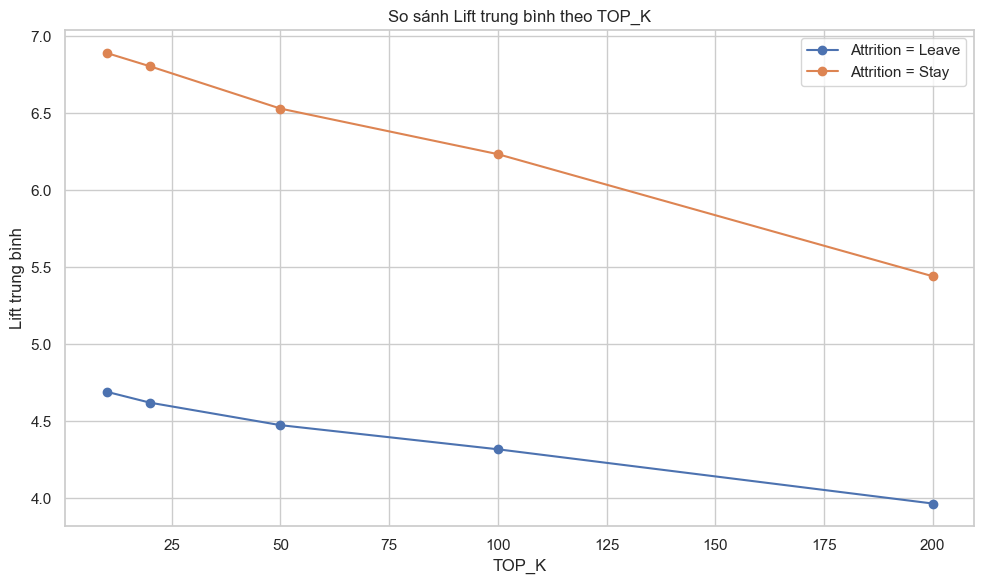

In [14]:
# So sánh Lift trung bình theo TOP_K
plt.figure(figsize=(10, 6))

plt.plot(
    df_topk_compare["TOP_K"],
    df_topk_compare["Leave_Lift_Mean"],
    marker="o",
    label="Attrition = Leave"
)

plt.plot(
    df_topk_compare["TOP_K"],
    df_topk_compare["Stay_Lift_Mean"],
    marker="o",
    label="Attrition = Stay"
)

plt.xlabel("TOP_K")
plt.ylabel("Lift trung bình")
plt.title("So sánh Lift trung bình theo TOP_K")
plt.legend()
plt.tight_layout()
plt.show()

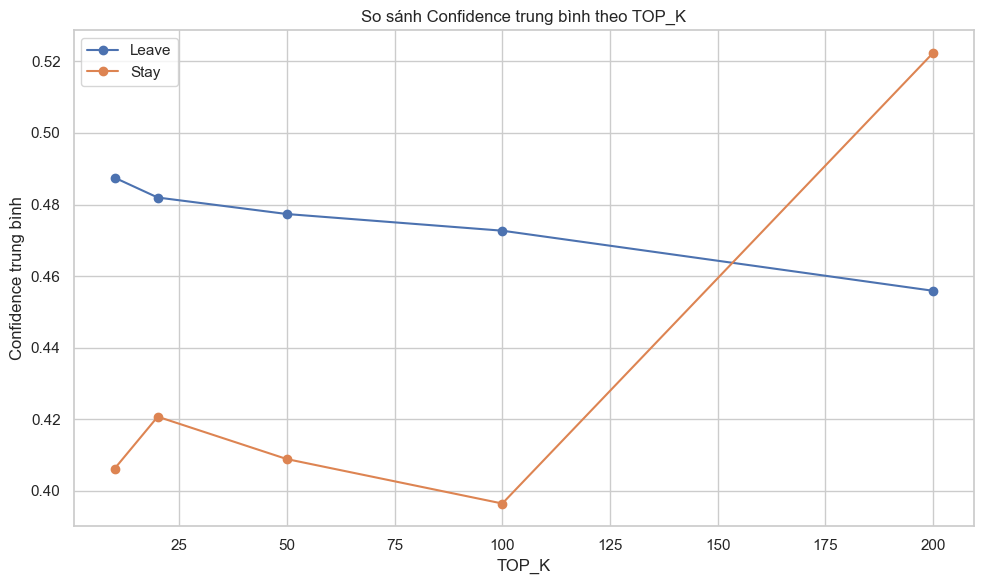

In [15]:
# Confidence trung bình theo TOP_K
plt.figure(figsize=(10, 6))

plt.plot(
    df_topk_compare["TOP_K"],
    df_topk_compare["Leave_Conf_Mean"],
    marker="o",
    label="Leave"
)

plt.plot(
    df_topk_compare["TOP_K"],
    df_topk_compare["Stay_Conf_Mean"],
    marker="o",
    label="Stay"
)

plt.xlabel("TOP_K")
plt.ylabel("Confidence trung bình")
plt.title("So sánh Confidence trung bình theo TOP_K")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# CHỐT TOP_K CUỐI CÙNG = 100
# =========================================================

FINAL_TOP_K = 100
print("=== 100 luật tiêu biểu (theo lift) sau khi lọc ===")
final_leave_rules = (
    leave_rules
    .sort_values("lift", ascending=False)
    .head(FINAL_TOP_K)
    .copy()
)

final_stay_rules = (
    stay_rules
    .sort_values("lift", ascending=False)
    .head(FINAL_TOP_K)
    .copy()
)

# =========================================================
# TẠO TÊN LUẬT ĐỂ DÙNG CHO TRỰC QUAN
# =========================================================

def format_rule(row):
    return f"{', '.join(row['antecedents'])} → {', '.join(row['consequents'])}"

final_leave_rules["rule_name"] = final_leave_rules.apply(format_rule, axis=1)
final_stay_rules["rule_name"]  = final_stay_rules.apply(format_rule, axis=1)

# =========================================================
# HIỂN THỊ BẢNG LUẬT (CÓ TÊN LUẬT)
# =========================================================

display(
    final_leave_rules[
        ["rule_name", "support", "confidence", "lift"]
    ]
)

display(
    final_stay_rules[
        ["rule_name", "support", "confidence", "lift"]
    ]
)

=== 10 luật tiêu biểu (theo lift) sau khi lọc ===


,rule_name,support,confidence,lift
21105,"Age_bin_nan, JobLevel_-0.963503753471408, Over...",0.049324,0.536765,4.756957
21133,"Age_bin_nan, TotalWorkingYears_bin_nan, Monthl...",0.049324,0.437126,4.756957
19710,"JobLevel_-0.963503753471408, OverTime_Yes_True...",0.049324,0.536765,4.756957
21136,"JobLevel_-0.963503753471408, OverTime_Yes_True...",0.049324,0.536765,4.756957
19727,"TotalWorkingYears_bin_nan, MonthlyIncome_bin_n...",0.049324,0.437126,4.756957
...,...,...,...,...
21089,"OverTime_Yes_True, TotalWorkingYears_bin_nan, ...",0.049324,0.500000,4.043716
18993,"AttritionLabel_Leave, YearsAtCompany_bin_nan →...",0.049324,0.398907,4.043716
19737,"AttritionLabel_Leave, YearsAtCompany_bin_nan →...",0.049324,0.398907,4.043716
19700,"TotalWorkingYears_bin_nan, JobLevel_-0.9635037...",0.049324,0.500000,4.043716


,rule_name,support,confidence,lift
14624,"Age_bin_nan, MonthlyIncome_bin_(0, 3000], Year...",0.025,0.486842,6.995401
12208,"MonthlyIncome_bin_(0, 3000], YearsAtCompany_bi...",0.025,0.486842,6.995401
14642,"MonthlyIncome_bin_(0, 3000], YearsAtCompany_bi...",0.025,0.486842,6.995401
12213,"TotalWorkingYears_bin_(0, 5], JobLevel_1.75093...",0.025,0.359223,6.995401
14645,"TotalWorkingYears_bin_(0, 5], JobLevel_1.75093...",0.025,0.359223,6.995401
...,...,...,...,...
8089,"Age_bin_nan, MonthlyIncome_bin_(0, 3000], JobL...",0.025,0.362745,5.772718
4946,"YearsAtCompany_bin_(2, 5] → MonthlyIncome_bin_...",0.025,0.397849,5.772718
12216,"TotalWorkingYears_bin_(0, 5], YearsAtCompany_b...",0.025,0.397849,5.772718
10532,"TotalWorkingYears_bin_(0, 5], YearsAtCompany_b...",0.025,0.397849,5.772718


# Trực quan hoá luật kết hợp

#### TOP LUẬT THEO LIFT (TOP_K = 100)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5928\4069872836.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


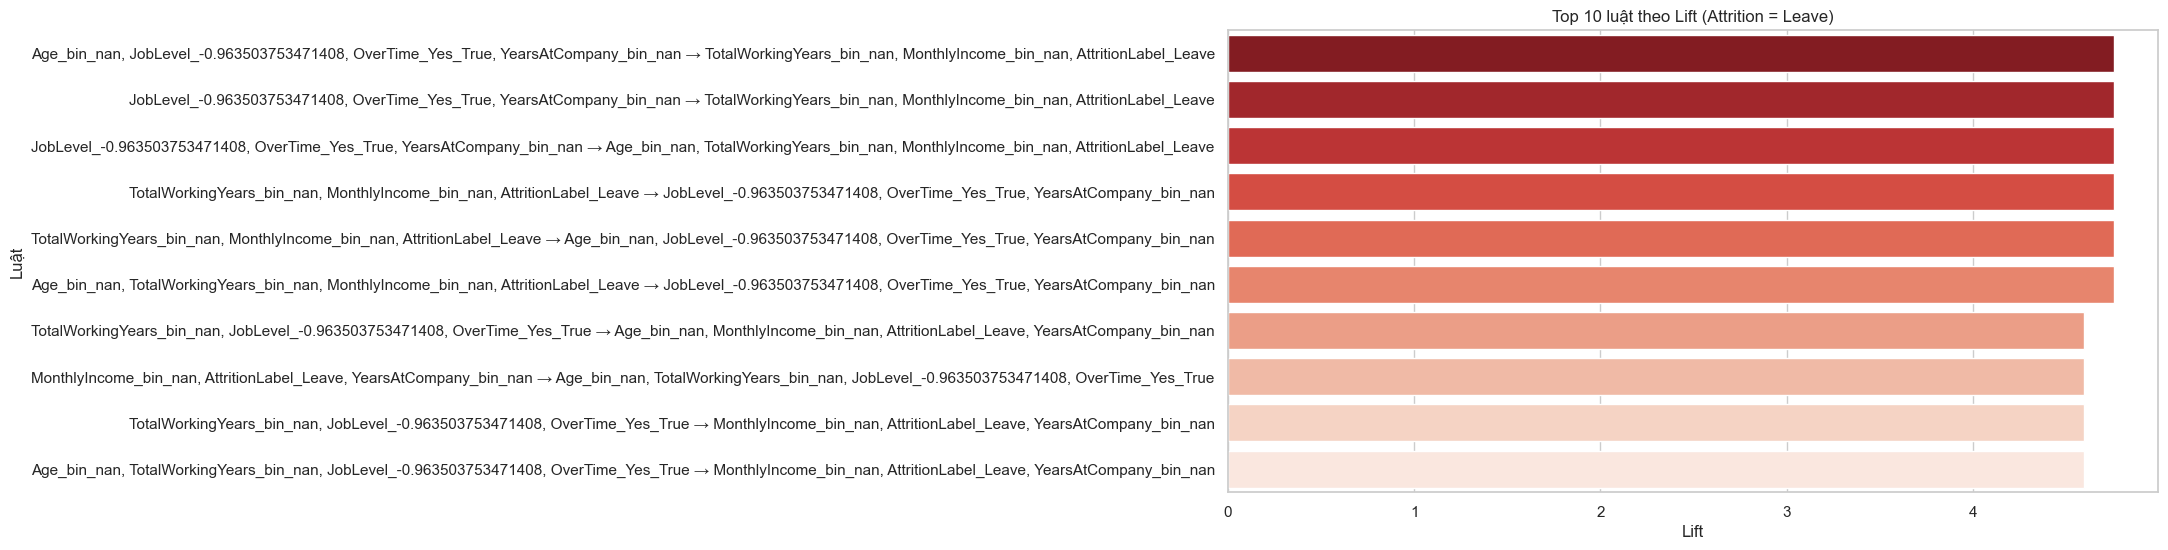

In [17]:
# Top luật theo Lift – Leave
top_lift_leave = final_leave_rules.sort_values("lift", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_lift_leave,
    x="lift",
    y="rule_name",
    palette="Reds_r"
)

plt.xlabel("Lift")
plt.ylabel("Luật")
plt.title("Top 10 luật theo Lift (Attrition = Leave)")
plt.tight_layout()
plt.show()

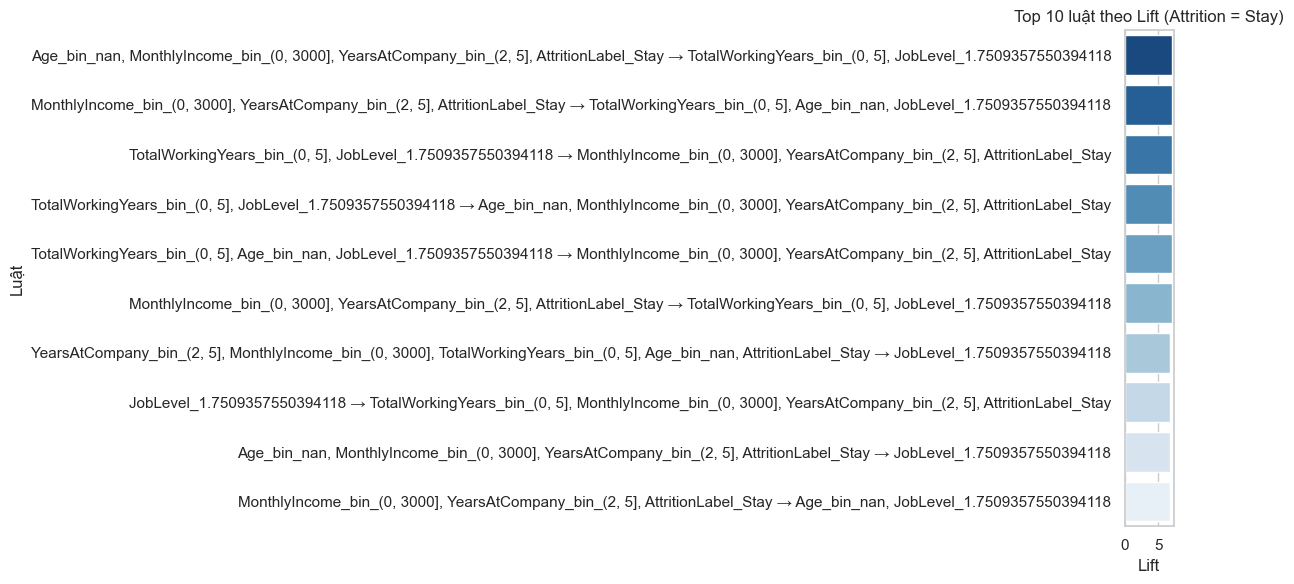

In [18]:
# Top luật theo Lift – Stay
top_lift_stay = final_stay_rules.sort_values("lift", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_lift_stay,
    x="lift",
    y="rule_name",
    palette="Blues_r"
)

plt.xlabel("Lift")
plt.ylabel("Luật")
plt.title("Top 10 luật theo Lift (Attrition = Stay)")
plt.tight_layout()
plt.show()

#### TOP LUẬT THEO CONFIDENCE (TOP_K = 100)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5928\3216593434.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


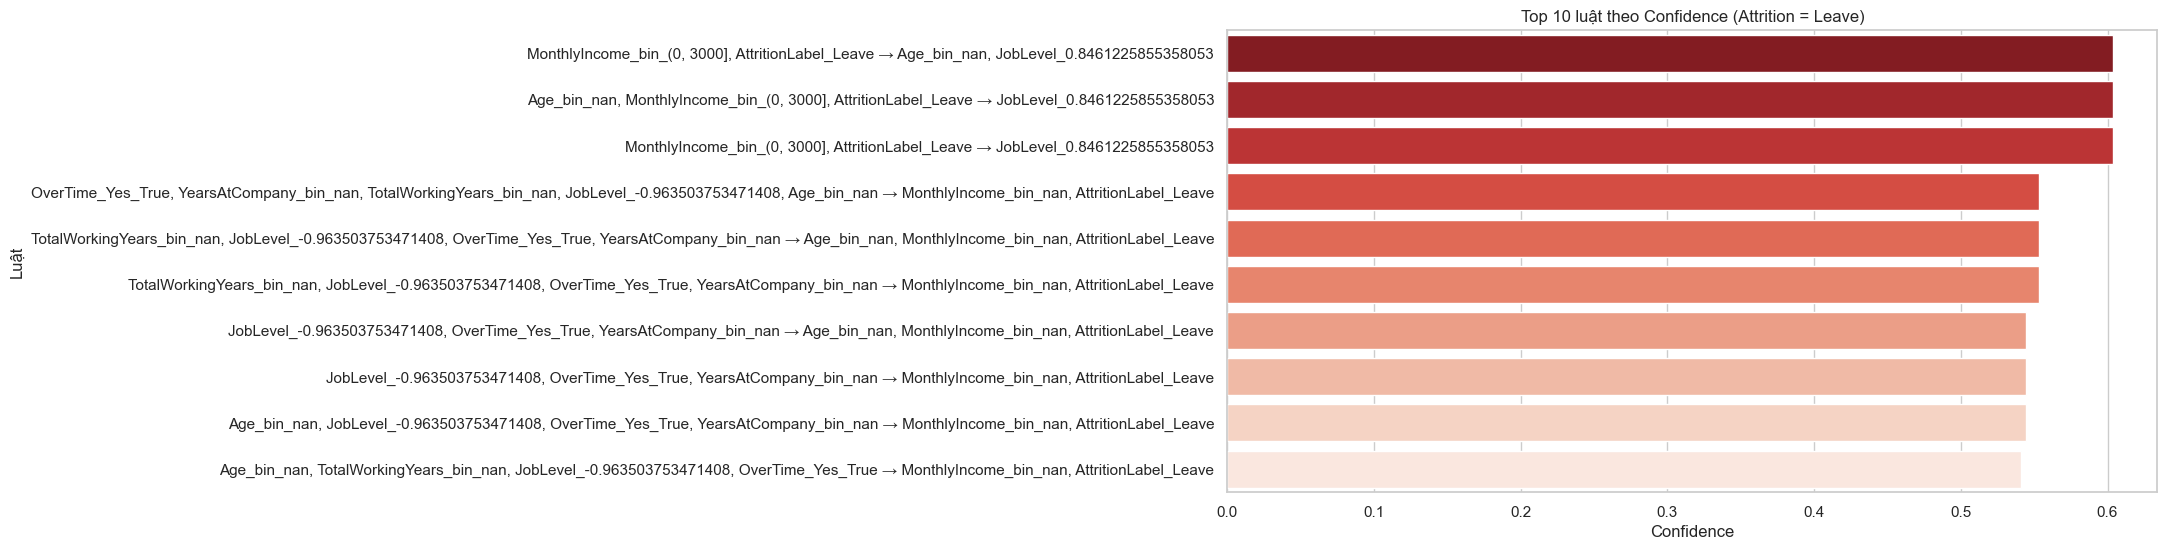

In [19]:
# Top luật theo Confidence – Leave
top_conf_leave = final_leave_rules.sort_values("confidence", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_conf_leave,
    x="confidence",
    y="rule_name",
    palette="Reds_r"
)

plt.xlabel("Confidence")
plt.ylabel("Luật")
plt.title("Top 10 luật theo Confidence (Attrition = Leave)")
plt.tight_layout()
plt.show()

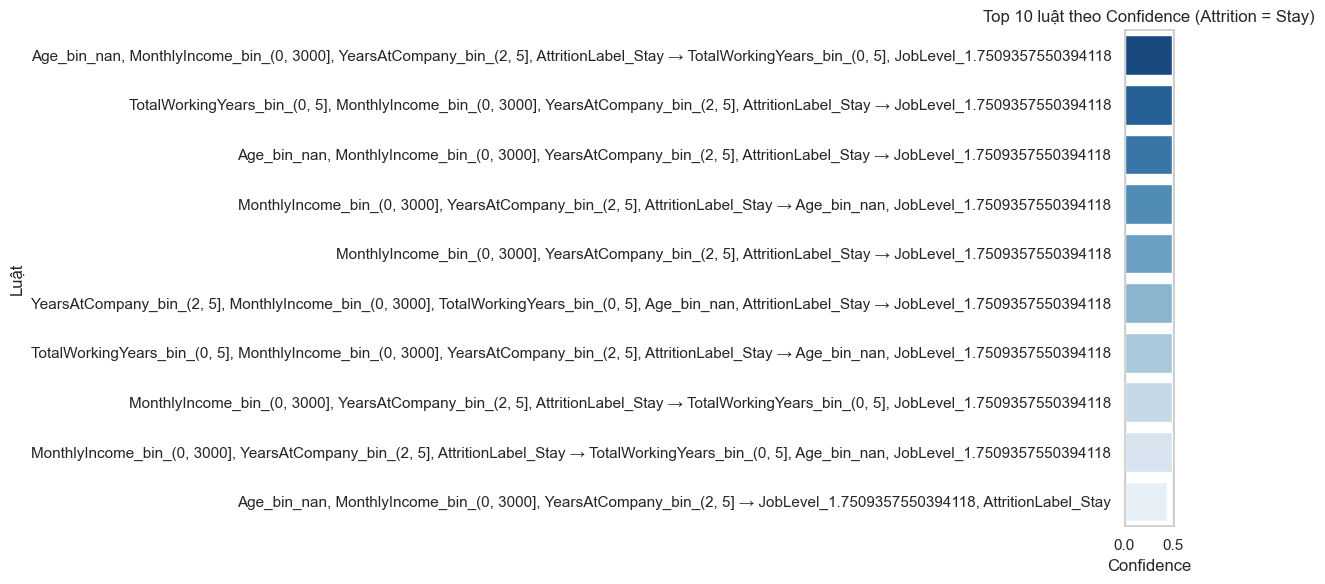

In [20]:
# Top luật theo Confidence – Stay
top_conf_stay = final_stay_rules.sort_values("confidence", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_conf_stay,
    x="confidence",
    y="rule_name",
    palette="Blues_r"
)

plt.xlabel("Confidence")
plt.ylabel("Luật")
plt.title("Top 10 luật theo Confidence (Attrition = Stay)")
plt.tight_layout()
plt.show()

#### SUPPORT VS CONFIDENCE (SCATTER PLOT)

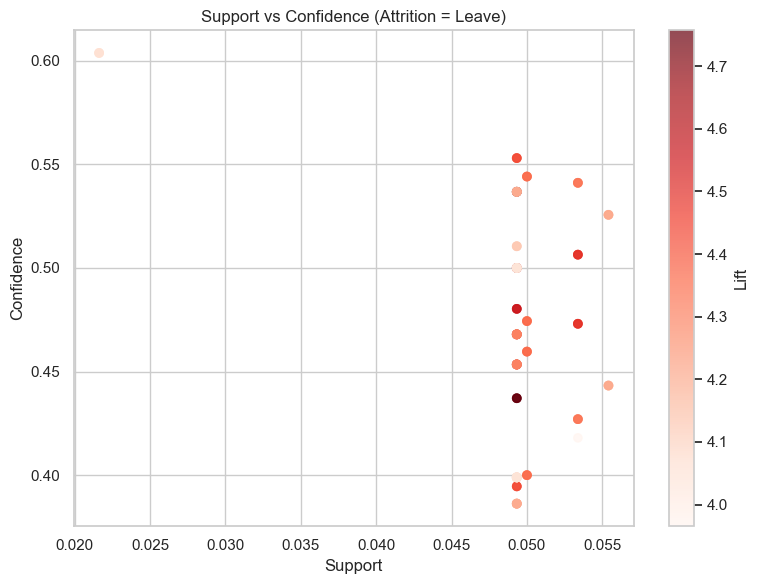

In [21]:
# Scatter Support – Confidence – Leave
plt.figure(figsize=(8, 6))
plt.scatter(
    final_leave_rules["support"],
    final_leave_rules["confidence"],
    c=final_leave_rules["lift"],
    cmap="Reds",
    alpha=0.7
)

plt.colorbar(label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (Attrition = Leave)")
plt.tight_layout()
plt.show()

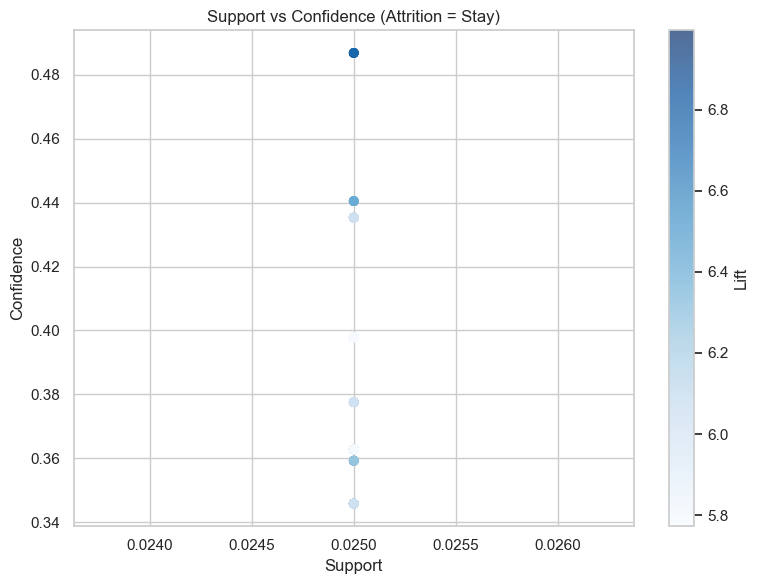

In [22]:
# Scatter Support – Confidence – Stay
plt.figure(figsize=(8, 6))
plt.scatter(
    final_stay_rules["support"],
    final_stay_rules["confidence"],
    c=final_stay_rules["lift"],
    cmap="Blues",
    alpha=0.7
)

plt.colorbar(label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (Attrition = Stay)")
plt.tight_layout()
plt.show()

In [23]:
# So sánh Lift & Confidence trung bình (Leave vs Stay)
summary_topk = pd.DataFrame({
    "Group": ["Leave", "Stay"],
    "Mean_Lift": [
        final_leave_rules["lift"].mean(),
        final_stay_rules["lift"].mean()
    ],
    "Mean_Confidence": [
        final_leave_rules["confidence"].mean(),
        final_stay_rules["confidence"].mean()
    ]
})

summary_topk

,Group,Mean_Lift,Mean_Confidence
0,Leave,4.319202,0.472703
1,Stay,6.234078,0.396496


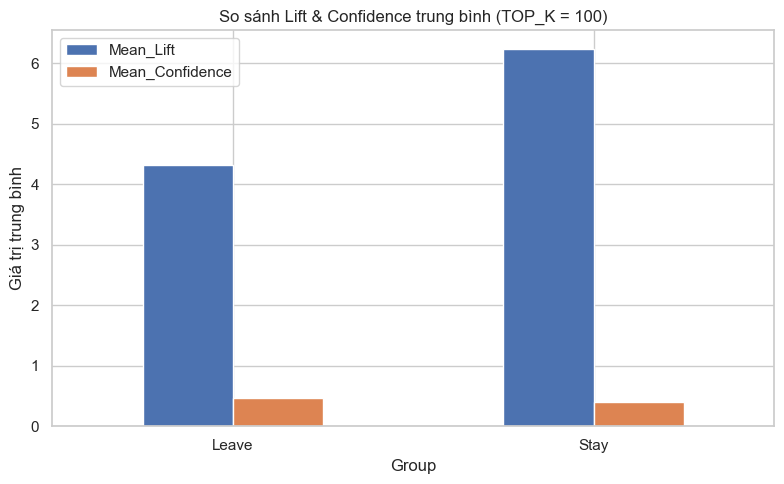

In [24]:
summary_topk.set_index("Group")[["Mean_Lift", "Mean_Confidence"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("So sánh Lift & Confidence trung bình (TOP_K = 100)")
plt.ylabel("Giá trị trung bình")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# =========================================================
# LƯU LUẬT APRIORI
# =========================================================

OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Toàn bộ luật Apriori (chưa lọc)
rules_ap.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_all.csv",
    index=False
)

# 2. Luật đã lọc theo support / confidence / lift
rules_filtered.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_filtered.csv",
    index=False
)

# 3. Top-K luật (đầu vào cho bước tiếp theo)
rules_topk.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_topk.csv",
    index=False
)

# 4. Luật liên quan đến Attrition = Leave
final_leave_rules.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_leave_top100.csv",
    index=False
)

# 5. Luật liên quan đến Attrition = Stay
final_stay_rules.to_csv(
    f"{OUTPUT_DIR}/rules_apriori_stay_top100.csv",
    index=False
)

print("✅ Đã lưu đầy đủ luật Apriori (TOP_K = 100):")
print("- rules_apriori_all.csv")
print("- rules_apriori_filtered.csv")
print("- rules_apriori_topk.csv")
print("- rules_apriori_leave_top100.csv")
print("- rules_apriori_stay_top100.csv")

✅ Đã lưu đầy đủ luật Apriori (TOP_K = 100):
- rules_apriori_all.csv
- rules_apriori_filtered.csv
- rules_apriori_topk.csv
- rules_apriori_leave_top100.csv
- rules_apriori_stay_top100.csv
